In [1]:
# Import necessary libraries
import numpy as np
import itertools
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# define constants for DQN
MAX_MEMORY = 10_000
BATCH_SIZE = 16
MIN_E = 0.05

In [2]:
# Function for creating the state change probabilities of the N stocks
def create_stock_probabilities(N):
    pr = np.zeros((4, N))
    for i in range(N):
        a = 0.4 #np.random.rand()
        b = 0.1 #np.random.rand()
        pr[0, i] = a    # Pr{H -> H}
        pr[1, i] = 1-a  # Pr{H -> L}
        pr[2, i] = b    # Pr{L -> H}
        pr[3, i] = 1-b  # Pr{L -> L}
    return pr

# Function for creating the mean rewards for each state of the N stocks
def create_means(N):
    mu = np.zeros((2, N))
    for i in range(N):
        mu[1, i] = 0.05 + np.random.rand() * 0.05
        mu[0, i] = -2*mu[1, i]/3 + 0.01 + (np.random.rand() * 0.04)
    return mu

# Function that returns a stock change in a certain range around its expected gain
def sample_reward(mean):
  return np.random.uniform(mean-0.01, mean+0.01)

In [3]:
# Policy Iteration
def create_state_space_PI(N):
    states = []
    phase_combinations = list(itertools.product([0, 1], repeat=N)) # create the different combinations of states. 0 for low and 1 for high

    # Add each stock to the beggining of every tuple and then each combination of stock states
    # N2^N states total
    for current_stock in range(N):
        for phases in phase_combinations:
            states.append((current_stock,) + phases)

    return states

# Creating the state directory to be used in Policy Iteration
def create_state_dict_PI(N, pr, mu, transaction_fee=0.01):
    states = create_state_space_PI(N)
    state_dict = {}

    for state in states:
        current_stock = state[0] # The stock we invest in is the first value in each state
        phases = state[1:]       # The stock phases take up the rest of the values (0s or 1s)
        state_dict[state] = {}

        # for each possible action (same N actions for every state)
        for action in range(N):
            state_dict[state][action] = []
            # for every possible next state
            for next_phases in itertools.product([0, 1], repeat=N):
                prob = 1
                # calculate the transition probabilities
                for i in range(N):
                    if phases[i] == 1:
                        prob *= pr[0, i] if next_phases[i] == 1 else pr[1, i]
                    else:
                        prob *= pr[2, i] if next_phases[i] == 1 else pr[3, i]

                # The next state is a tuple (action, next_phase_stock1, next_phase_stock2, ..., next_phase_stockN)
                next_state = (action,) + next_phases
                # The reward is set to the mean reward of the stock we choose (according to its phase)
                reward = mu[next_phases[action], action]

                if current_stock != action:
                    reward -= transaction_fee  # If we switch stocks then subtract a transaction fee from the profits

                terminal = False  # No terminal states
                state_dict[state][action].append((prob, next_state, reward, terminal))

    return state_dict

# mapping from state tuple (i, {0,1}^N) -> unique positive integer
def create_state_index_mapping_PI(states):
    return {state: index for index, state in enumerate(states)}


def policy_evaluation(pi, P, state_index_mapping, gamma=0.1, epsilon=1e-10):
    t = 0
    num_states = len(state_index_mapping)
    prev_V = np.zeros(num_states)  # use as "cost-to-go", i.e. for V(s')

    while True:
        V = np.zeros(num_states)  # current value function to be learned
        for state in P:  # do for every state
            s = state_index_mapping[state]
            for prob, next_state, reward, done in P[state][pi(state)]:  # calculate one Bellman step
                next_s = state_index_mapping[next_state]
                V[s] += prob * (reward + gamma * prev_V[next_s])

        #print(np.abs(prev_V - V))
        if np.max(np.abs(prev_V - V)) < epsilon:  # check if the new V estimate is close enough to the previous one
            break  # if yes, finish loop

        prev_V = V.copy()  # freeze the new values (to be used as the next V(s'))
        t += 1

    return V

def policy_improvement(V, P, state_index_mapping, gamma=1.0):
    num_states = len(state_index_mapping)
    Q = np.zeros((num_states, len(P[next(iter(P))])), dtype=np.float64)  # create a Q value array

    for state in P:  # for every state in the environment/model
        s = state_index_mapping[state]
        for action in P[state]:  # and for every action in that state
            for prob, next_state, reward, done in P[state][action]:  # evaluate the action value
                next_s = state_index_mapping[next_state]
                Q[s][action] += prob * (reward + gamma * V[next_s] * (not done))

    new_pi = lambda state: np.argmax(Q[state_index_mapping[state]])  # create the new (improved) policy
    return new_pi

def policy_iteration(P, gamma=1.0, epsilon=1e-10):
    states = list(P.keys())
    state_index_mapping = create_state_index_mapping_PI(states)

    num_states = len(states)
    random_actions = np.random.choice(list(P[states[0]].keys()), num_states)  # start with random actions for each state
    pi = lambda state: random_actions[state_index_mapping[state]]  # define your initial policy pi_0

    while True:
        old_pi = {state: pi(state) for state in states}  # keep the old policy to compare with new
        V = policy_evaluation(pi, P, state_index_mapping, gamma, epsilon)  # evaluate the latest policy
        pi = policy_improvement(V, P, state_index_mapping, gamma)  # get a better policy

        if old_pi == {state: pi(state) for state in states}:  # check for convergence
            break

    return V, pi

In [4]:
# Tabular Q-Learning
def create_state_space_Q(N):
    # return states, phase_combinations
    states = {}
    phase_combinations = list(itertools.product([0, 1], repeat=N))  # Create the different combinations of states. 0 for low and 1 for high

    index = 0
    # Add each stock to the beginning of every tuple and then each combination of stock states
    # N * 2^N states total
    for current_stock in range(N):
        for phases in phase_combinations:
            state_list = [current_stock] + list(phases)  # Convert the tuple to a list
            states[tuple(state_list)] = index  # Store as a tuple to maintain hashability
            index += 1

    return states, phase_combinations

# Function used to map every state-tuple to an integer
def create_state_index_mapping_Q(states):
    return {state: index for index, state in enumerate(states)}

#Get the action using the Q-table with epsilon-greedy exploration
def get_action_Q(state, Q, N, epsilon):
  # random moves: tradeoff exploration / exploitation
  rnd = np.random.rand()
  if rnd < epsilon :
    return np.random.randint(0,N) #choose action randomly (explore)
  else:
    return np.argmax(Q[state])    #pick seemingly best action (exploit)

# simulating a day change. Returns new state and reward based on the action chosen on the previous day
def play_step_Q(S, state, pr, mu, new_stock, map, fee):
  N = len(state)-1
  phases = np.zeros(N, dtype=int)
  old_stock = state[0]

  # Go to a random new state according to the transition probabilities
  for i in range(N):
    phase_curr = state[i+1]
    if(phase_curr == 1):
      m = np.random.rand()
      if(m < pr[0, i]):
        phases[i] = 1 #H ->H
      else:
        phases[i] = 0 #H ->L
    else:
      m = np.random.rand()
      if(m < pr[2, i]):
        phases[i] = 1 #L ->H
      else:
        phases[i] = 0 #L ->L

  reward = sample_reward(mu[phases[new_stock], new_stock])

  # Subtract the fee if we switch stocks
  if(old_stock != new_stock):
    reward -= fee

  # Create and return the new state
  next_state = (new_stock,) + tuple(phases)
  return[next_state, reward]


def tab_Q_learning(S,P,pr,mu, fee=10e-2, episode_length=100000, gamma=0.1, lr=0.001, eps=1):
  idx_map = create_state_index_mapping_Q(list(S.keys()))

  #init Q table
  Q  = np.zeros((N*(2**N), N))

  # run a number (eps) of episodes
  for j in range(eps):
    #create a semi-random initial state
    s = np.random.binomial(1, p=0.2, size=N)
    s = (j%N,) + tuple(s)
    old_state = s

    for i in range(episode_length):
      #epsilon = max(1/(i+1), 0.001)
      epsilon = 1/(i+1)
      #epsilon = 0.002

      #choose action (e-greedy)
      action = get_action_Q(idx_map[old_state], Q, N, epsilon)

      #simulate the changes for a day
      [new_state, reward] = play_step_Q(S, old_state, pr, mu, action, idx_map, fee) #Get the new state and reward

      #update the Q-table
      Q[idx_map[old_state], action] = Q[idx_map[old_state], action] + lr*(reward + gamma*np.max(Q[idx_map[new_state]]) - Q[idx_map[old_state], action])

      old_state = new_state

  # Extract the "optimal" policy
  pi_star = lambda state: np.argmax(Q[idx_map[state]])  # create the new (improved) policy
  return pi_star

In [5]:
# Deep Q-Learning
def create_model(in_size, hidden_size, out_size, lr):
  model = nn.Sequential(
      nn.Linear(in_size, hidden_size),  #linear input layer
      nn.ReLU(),  #activation func
      nn.Linear(hidden_size, hidden_size), #linear hidden layer
      nn.ReLU(),  #activation func
      nn.Linear(hidden_size, out_size) #linear output layer
  )
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  crit = nn.MSELoss()
  return [model, optimizer, crit]

def get_state_DQN(curr_stock, phases):
    N = len(phases)
    # Create a state vector of size N+1
    state = np.zeros(N+1, dtype=np.float32)

    # Set the first position to the current stock
    state[0] = curr_stock

    # Set the next N positions to the stock phases
    state[1:N+1] = phases
    return state

def get_state_DQN2(curr_stock, changes):
    N = len(changes)
    # Create a state vector of size N+1
    state = np.zeros(N+1, dtype=np.float32)

    # Set the first position to the current stock
    state[0] = curr_stock

    # Set the next N positions to the stock phases
    state[1:N+1] = changes*10
    return state

# append tuple (s, a, r, s') in the memory
def remember(memory, state, action, reward, next_state):
  memory.append((state, action, reward, next_state)) # popleft if MAX_MEMORY is reached

# choose action (e-greedy)
def get_action_DQN(model, state, N, epsilon):
  rnd = np.random.rand()
  if rnd < epsilon :
    action = np.random.randint(0,N) #choose action randomly (explore)
  else:
    state = torch.tensor(state, dtype=torch.float32)
    prediction = model(state)  # forward pass to get the action vector
    prediction = prediction.detach().numpy()
    action = np.argmax(prediction) #pick seemingly best action (exploit)
  return action

# simulating a day change. Returns new state and reward based on the action chosen on the previous day
def play_step_DQN(phases, old_stock, new_stock, mu, pr, fee):
  N = len(phases)
  changes = np.zeros(N)

  # change stock phases and rewards according to the environment
  for i in range(N):
    phase_curr = phases[i]
    if(phase_curr == 1):
      m = np.random.rand()
      if(m < pr[0, i]):
        phases[i] = 1 #H->H
      else:
        phases[i] = 0 #H->L
    else:
      m = np.random.rand()
      if(m < pr[2, i]):
        phases[i] = 1 #L->H
      else:
        phases[i] = 0 #L->L
    changes[i] = sample_reward(mu[int(phases[i]), i])

  reward = changes[new_stock]
  if(old_stock != new_stock): #subtract the fee when switching stocks
    reward = reward - fee

  # get the new state
  #new_state = get_state_DQN(new_stock, phases)
  new_state = get_state_DQN2(new_stock, changes)
  return new_state, reward, phases


# Train the NN (model) with a random batch of tuples from the memory
def train_step(memory, T_model, model, optimizer, criterion, old_state, action, reward, new_state, gamma):
  if len(memory) < BATCH_SIZE:
      return

  # Get a random batch
  mini_sample = random.sample(memory, BATCH_SIZE)
  states, actions, rewards, next_states = zip(*mini_sample)

  # turn everything to tensors
  states = torch.tensor(np.array(states), dtype=torch.float32)
  actions = torch.tensor(actions, dtype=torch.long)
  rewards = torch.tensor(rewards, dtype=torch.float32)
  next_states = torch.tensor(next_states, dtype=torch.float32)

  Q_values = model(states)   #(batch_size, N-d arrays)
  T_values = T_model(next_states)
  max_T_values, _ = torch.max(T_values, dim=1)
  targets = rewards + gamma * max_T_values
  q = torch.gather(Q_values, 1, actions.unsqueeze(1)).squeeze(1)

  # update the model parameters
  loss = criterion(targets, q)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


def DQL(memory, T_model, model, optimizer, criterion, N, mu, pr, num_ep, ep_length, gamma, fee):
  changes = np.zeros(N, dtype=float)
  for i in range(num_ep):
    # calculate epsilon for each episode
    epsilon = MIN_E + (1-MIN_E)*np.exp(-0.01*i)

    # choose a semi-random initial state
    curr_stock = i % N
    phases = np.random.binomial(1, p=0.2, size=N)
    #old_state = get_state_DQN(curr_stock, phases)
    old_state = get_state_DQN2(curr_stock, changes)

    for j in range(ep_length):
      #pick action (e-greedy)
      action = get_action_DQN(model, old_state, N, epsilon)

      #simulate a day
      [new_state, reward, phases] = play_step_DQN(phases, curr_stock, action, mu, pr, fee)

      #store episode step in the memory
      remember(memory, old_state, action, reward, new_state)

      #train the model
      train_step(memory, T_model, model, optimizer, criterion, old_state, action, reward, new_state, gamma)

      #every x steps change the parameters of the target network
      if i % 20 == 0:
        T_model.load_state_dict(model.state_dict())

      old_state = new_state
      curr_stock = action

  # Extract the "optimal" policy
  def pi_star(state):
      state = torch.tensor(state, dtype=torch.float32)
      q_values = model(state.unsqueeze(0))  # Predict Q-values for the state
      action_idx = torch.argmax(q_values).item()  # Choose action with max Q-value
      return action_idx

  return pi_star

In [6]:
# Create the behaviour of the stocks
N = 3
mu = create_means(N)
pr = create_stock_probabilities(N)

In [7]:
# algorithm parameters
fee = 0.01
lr_Q = 0.001
lr_DQN = 0.001
gamma = 0.90

ep_length_Q = 1000000
eps_Q = 1

eps_DQN = 200
ep_length_DQN = 200

# Policy Iteration
env = create_state_dict_PI(N, pr, mu, fee)
[V_star, pi_star_PI] = policy_iteration(env, gamma, 1e-5)

# Tabular Q-Learning
[S, P] = create_state_space_Q(N)
pi_star_Q = tab_Q_learning(S,P, pr,mu, fee, ep_length_Q, gamma, lr_Q, eps_Q)

# Deep Q-Learning
[model, optimizer, criterion] = create_model(N+1, 128, N, lr_DQN)
[T_model, junk1, junk2] = create_model(N+1, 128, N, lr_DQN)
T_model.load_state_dict(model.state_dict())
T_model.eval()
memory = deque(maxlen=MAX_MEMORY) # popleft()
pi_star_DQN = DQL(memory, T_model, model, optimizer, criterion, N, mu, pr, eps_DQN, ep_length_DQN, gamma, fee)

<ipython-input-5-6216cafa6bc9>:99: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  next_states = torch.tensor(next_states, dtype=torch.float32)


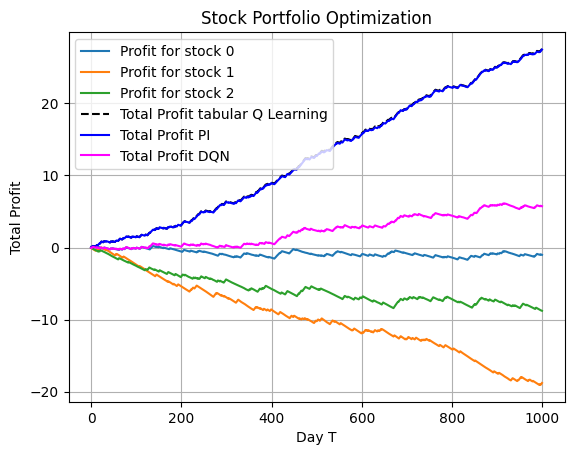

In [9]:
T = 1000

changes = np.zeros(N, dtype=float)
phases = np.random.binomial(1, p=0.2, size=N)

curr_stock = np.random.randint(0, N)

# start every algorithm with the same initial state
state_Q = (curr_stock,) + tuple(phases[i] for i in range(N))
state_PI = (curr_stock,) + tuple(phases[i] for i in range(N))
#state_DQN = get_state_DQN(curr_stock, phases)
state_DQN = get_state_DQN2(curr_stock, changes)

#initialize variables
stock_profits = np.zeros((N,T))
profit_Q = np.zeros(T)
profit_PI = np.zeros(T)
profit_DQN = np.zeros(T)
prev_action_Q = 0
prev_action_PI = 0
prev_action_DQN = 0

# main testing loop
for t in range(T):
  action_star_Q = pi_star_Q(state_Q)
  action_star_PI = pi_star_PI(state_PI)
  action_star_DQN = pi_star_DQN(state_DQN)

  #change phases and sample rewards
  for i in range(N):
    if (phases[i]==0): # a stock is in L
      # L -> H or L -> L
      changes[i] = sample_reward(mu[0,i])
      phases[i] = np.random.binomial(1, pr[2,i])
    else:
      # H -> L or H -> H
      changes[i] = sample_reward(mu[1,i])
      phases[i] = np.random.binomial(1, pr[1,i])
    stock_profits[i, t] = stock_profits[i, t-1] + changes[i]

  #add profits and update states and actions
  profit_Q[t] = profit_Q[t-1] + changes[action_star_Q]
  if(action_star_Q != prev_action_Q):
    profit_Q[t] -= fee
  prev_action_Q = action_star_Q

  profit_PI[t] = profit_PI[t-1] + changes[action_star_PI]
  if(action_star_PI != prev_action_PI):
    profit_PI[t] -= fee
  prev_action_PI = action_star_PI

  profit_DQN[t] = profit_DQN[t-1] + changes[action_star_DQN]
  if(action_star_DQN != prev_action_DQN):
    profit_DQN[t] -= fee
  prev_action_DQN = action_star_DQN

  state_Q = (action_star_Q,) + tuple(phases[i] for i in range(N))
  state_PI = (action_star_PI,) + tuple(phases[i] for i in range(N))
  #state_DQN = get_state_DQN(action_star_DQN, phases)
  state_DQN = get_state_DQN2(action_star_DQN, changes)

#Plot the results
plt.title("Stock Portfolio Optimization")
plt.xlabel("Day T")
plt.grid(True)
plt.ylabel("Total Profit")
for i in range(N):
    plt.plot(np.arange(0,T), stock_profits[i,:T], label=f'Profit for stock {i}')

plt.plot(np.arange(0,T), profit_Q, color='black', linestyle='--', label='Total Profit tabular Q Learning')
plt.plot(np.arange(0,T), profit_PI, color='blue', label='Total Profit PI')
plt.plot(np.arange(0,T), profit_DQN, color='magenta', label='Total Profit DQN')


plt.legend()
plt.show()